# Análise Exploratória de Dados (EDA) - Alfabetização Infantil
Neste notebook, realizaremos a EDA para compreender as variáveis que impactam a alfabetização.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações visuais
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)


## 1. Leitura e Estrutura dos Dados

In [2]:
# Lendo o parquet
df = pd.read_parquet('../data/raw/abt_alunos_alfabetizacao.parquet')

# Exibindo as primeiras linhas e informações gerais
display(df.head())
df.info()

,id_aluno,id_escola,id_municipio,y_alfabetizado_label,y_alfabetizado,ano,serie,rede,sigla_uf,nome_regiao,nome_municipio,qtd_alunos_escola,qtd_alunos_municipio,qtd_escolas_municipio,w_peso_aluno,ref_meta_taxa_ano,leak_proficiencia
0,11019605,60000159,1100015,Sim,1,2023,2° ano do Ensino Fundamental,Municipal,RO,Norte,Alta Floresta D'Oeste,24,227,5,1.083333,NaN,802.969529
1,11019624,60000161,1100015,Sim,1,2023,2° ano do Ensino Fundamental,Municipal,RO,Norte,Alta Floresta D'Oeste,45,227,5,1.127451,NaN,799.911558
2,11019780,60000382,1100015,Sim,1,2023,2° ano do Ensino Fundamental,Municipal,RO,Norte,Alta Floresta D'Oeste,70,227,5,0.971731,NaN,841.216969
3,11019589,60000159,1100015,Sim,1,2023,2° ano do Ensino Fundamental,Municipal,RO,Norte,Alta Floresta D'Oeste,24,227,5,1.083333,NaN,802.969529
4,11019737,60000337,1100015,Não,0,2023,2° ano do Ensino Fundamental,Municipal,RO,Norte,Alta Floresta D'Oeste,84,227,5,1.163368,NaN,704.503154


<class 'pandas.DataFrame'>
RangeIndex: 167791 entries, 0 to 167790
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id_aluno               167791 non-null  str    
 1   id_escola              167791 non-null  str    
 2   id_municipio           167791 non-null  str    
 3   y_alfabetizado_label   167791 non-null  str    
 4   y_alfabetizado         167791 non-null  Int64  
 5   ano                    167791 non-null  Int64  
 6   serie                  167791 non-null  str    
 7   rede                   167791 non-null  str    
 8   sigla_uf               167791 non-null  str    
 9   nome_regiao            167791 non-null  str    
 10  nome_municipio         167791 non-null  str    
 11  qtd_alunos_escola      167791 non-null  Int64  
 12  qtd_alunos_municipio   167791 non-null  Int64  
 13  qtd_escolas_municipio  167791 non-null  Int64  
 14  w_peso_aluno           167791 non-null  float64

## 2. Análise da Variável Target
A variável alvo é `y_alfabetizado` (1 para alfabetizado, 0 para não alfabetizado).

C:\Users\felyp\AppData\Local\Temp\ipykernel_8932\3925107776.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='y_alfabetizado', palette='Set2')


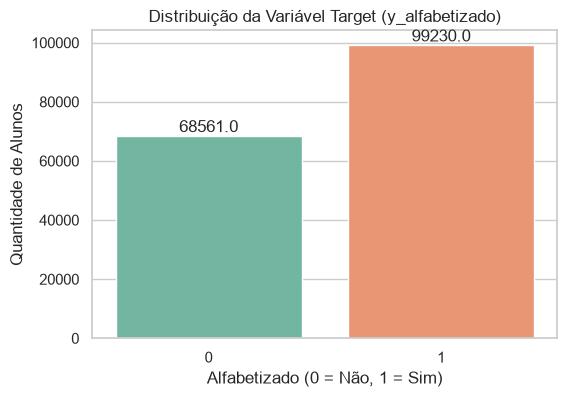

Proporção das classes:
y_alfabetizado
1    59.139048
0    40.860952
Name: proportion, dtype: Float64


In [3]:
# Contagem de classes
plt.figure(figsize=(6, 4))
ax = sns.countplot(data=df, x='y_alfabetizado', palette='Set2')
plt.title('Distribuição da Variável Target (y_alfabetizado)')
plt.xlabel('Alfabetizado (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade de Alunos')

# Adicionando rótulos
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')
plt.show()

print("Proporção das classes:")
print(df['y_alfabetizado'].value_counts(normalize=True) * 100)

## 3. Remoção de Variáveis de Data Leakage
Como definido na extração, a coluna `leak_proficiencia` determina o target. Se mantida, o modelo terá 100% de acerto artificial. Também removeremos identificadores (`id_aluno`, `id_escola`, etc.) que não generalizam.

In [4]:
# Definindo colunas a serem removidas para a modelagem
cols_to_drop = [
    'id_aluno', 'id_escola', 'id_municipio', 
    'y_alfabetizado_label', 'leak_proficiencia'
]
df_model = df.drop(columns=cols_to_drop)
print(f"Dataset reduzido de {df.shape[1]} para {df_model.shape[1]} colunas.")

Dataset reduzido de 17 para 12 colunas.


## 4. Análise de Variáveis Categóricas
Vamos verificar a taxa de alfabetização por Rede (Estadual, Municipal, etc.) e por Região do Brasil.

C:\Users\felyp\AppData\Local\Temp\ipykernel_8932\3690426377.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='rede', y='y_alfabetizado', palette='Pastel1', errorbar=None)


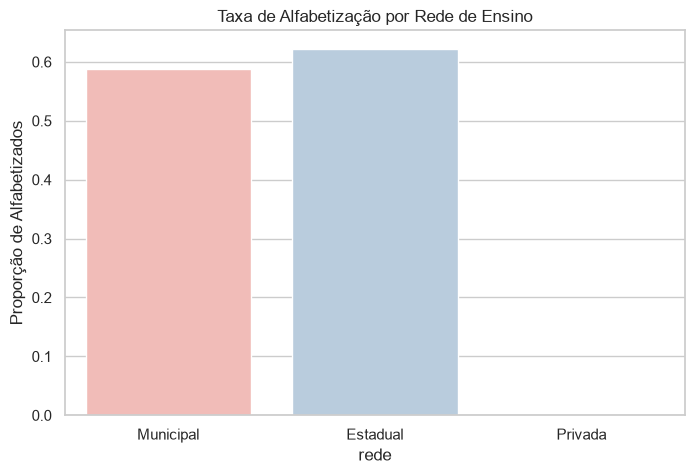

C:\Users\felyp\AppData\Local\Temp\ipykernel_8932\3690426377.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_model, x='nome_regiao', y='y_alfabetizado', palette='Pastel2', errorbar=None)


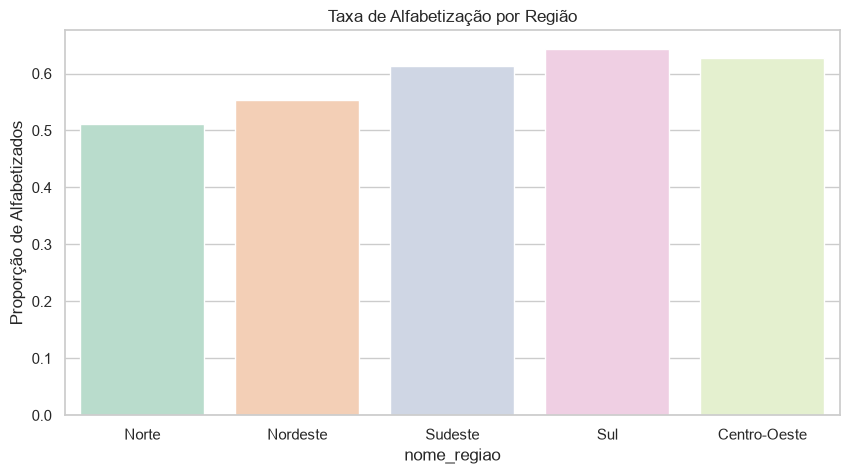

In [5]:
# Taxa de alfabetização por Rede
plt.figure(figsize=(8, 5))
sns.barplot(data=df_model, x='rede', y='y_alfabetizado', palette='Pastel1', errorbar=None)
plt.title('Taxa de Alfabetização por Rede de Ensino')
plt.ylabel('Proporção de Alfabetizados')
plt.show()

# Taxa de alfabetização por Região
plt.figure(figsize=(10, 5))
sns.barplot(data=df_model, x='nome_regiao', y='y_alfabetizado', palette='Pastel2', errorbar=None)
plt.title('Taxa de Alfabetização por Região')
plt.ylabel('Proporção de Alfabetizados')
plt.show()

## 5. Análise de Variáveis Numéricas (Porte)

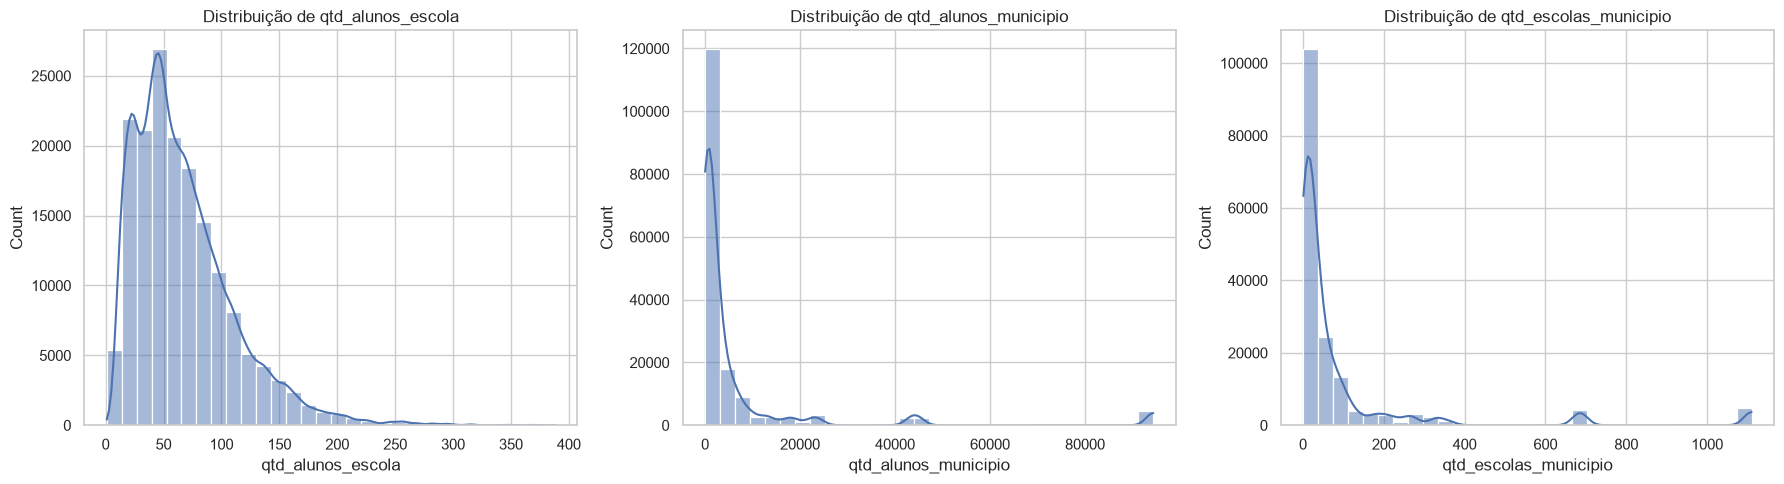

In [6]:
num_cols = ['qtd_alunos_escola', 'qtd_alunos_municipio', 'qtd_escolas_municipio']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(num_cols):
    sns.histplot(df_model[col], bins=30, ax=axes[i], kde=True)
    axes[i].set_title(f'Distribuição de {col}')
plt.tight_layout()
plt.show()

## 6. Correlação Numérica
Verificando a correlação de Spearman (já que as distribuições não são normais).

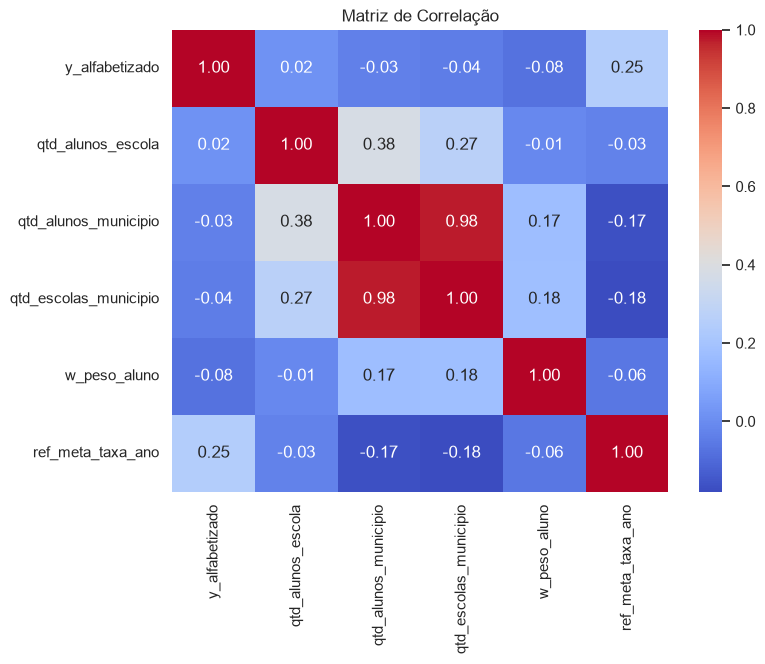

In [7]:
plt.figure(figsize=(8, 6))
# Calculando correlação de Spearman para numéricas contínuas (inclusive o peso e target)
cols_corr = num_cols + ['w_peso_aluno', 'ref_meta_taxa_ano']
# Criando subset e tratando NaN temporariamente apenas para correlação
corr = df_model[['y_alfabetizado'] + cols_corr].astype(float).corr(method='spearman')
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlação')
plt.show()

## 7. Conclusões da Análise Exploratória (EDA)

Com base nas visualizações e nos dados extraídos, tiramos as seguintes conclusões estratégicas para a modelagem:

1. **Balanceamento da Variável Alvo (Target):**
   - A base é relativamente **balanceada**, com cerca de 59,1% dos alunos alfabetizados (1) e 40,8% não alfabetizados (0). Isso é muito positivo para o aprendizado de máquina, pois indica que provavelmente não precisaremos usar técnicas pesadas de balanceamento sintético (como SMOTE). Métricas como **F1-Score** e **ROC-AUC** serão adequadas para avaliação.

2. **Disparidades por Rede e Região:**
   - **Região:** Notamos uma evidente disparidade regional. As regiões **Sul, Sudeste e Centro-Oeste** apresentam as maiores proporções de alunos alfabetizados (na faixa de 60%). Em contrapartida, as regiões **Nordeste e Norte** apresentam as menores taxas (entre 51% e 55%). Isso indica que a variável geográfica tem peso significativo.
   - **Rede:** A rede **Estadual** apresentou uma taxa de alfabetização (aprox. 62%) ligeiramente superior à rede **Municipal** (aprox. 59%).

3. **Comportamento das Variáveis Numéricas (Porte):**
   - As variáveis numéricas referentes à quantidade de alunos e escolas possuem uma distribuição fortemente assimétrica à direita (*long tail*). A esmagadora maioria tem porte menor, com a existência de poucos *outliers* significativos (escolas ou municípios gigantes).

4. **Correlações e Decisão de Modelagem:**
   - A Matriz de Correlação de Spearman indicou que as variáveis numéricas de porte possuem **correlação linear praticamente nula** com a variável target (valores entre -0.04 e 0.02).
   - A variável com maior correlação positiva direta com a alfabetização é a `ref_meta_taxa_ano` (0.25).
   - **Decisão:** Como a relação linear da maioria das variáveis numéricas com o target é muito fraca, modelos lineares puros (ex: Regressão Logística) tendem a não performar tão bem. Nosso cenário depende de interações complexas (não-lineares) e do peso das variáveis categóricas (como Região e Rede). Portanto, **modelos baseados em árvores (Random Forest, XGBoost ou LightGBM)** são a escolha mais robusta para a próxima etapa.